In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
%matplotlib inline

In [19]:
# Load encoded latents and decode intermediate activations
import torch
from encodec import EncodecModel

model = EncodecModel.encodec_model_24khz()
model.eval()


EncodecModel(
  (encoder): SEANetEncoder(
    (model): Sequential(
      (0): SConv1d(
        (conv): NormConv1d(
          (conv): Conv1d(1, 32, kernel_size=(7,), stride=(1,))
          (norm): Identity()
        )
      )
      (1): SEANetResnetBlock(
        (block): Sequential(
          (0): ELU(alpha=1.0)
          (1): SConv1d(
            (conv): NormConv1d(
              (conv): Conv1d(32, 16, kernel_size=(3,), stride=(1,))
              (norm): Identity()
            )
          )
          (2): ELU(alpha=1.0)
          (3): SConv1d(
            (conv): NormConv1d(
              (conv): Conv1d(16, 32, kernel_size=(1,), stride=(1,))
              (norm): Identity()
            )
          )
        )
        (shortcut): SConv1d(
          (conv): NormConv1d(
            (conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
            (norm): Identity()
          )
        )
      )
      (2): ELU(alpha=1.0)
      (3): SConv1d(
        (conv): NormConv1d(
          (conv): Co

In [ ]:
# Load encoded frames from latents (class 0)
latent_file = sorted(Path("../data/encoded_latents_16khz/encodec/0").glob("*.npy"))[0]
frames_data = np.load(latent_file)
print(f"Loaded {latent_file.name}, shape: {frames_data.shape}")

# Convert to tensor (indices) and decode
with torch.no_grad():
    codes = torch.from_numpy(frames_data).long().unsqueeze(0).unsqueeze(0)  # [1, 1, n]
    emb = model.quantizer.decode(codes)
    audio_latent = model.decoder.model[:2](emb)
    print(f"Audio latent shape: {audio_latent.shape}")

Loaded 000193.npy, shape: (80100,)


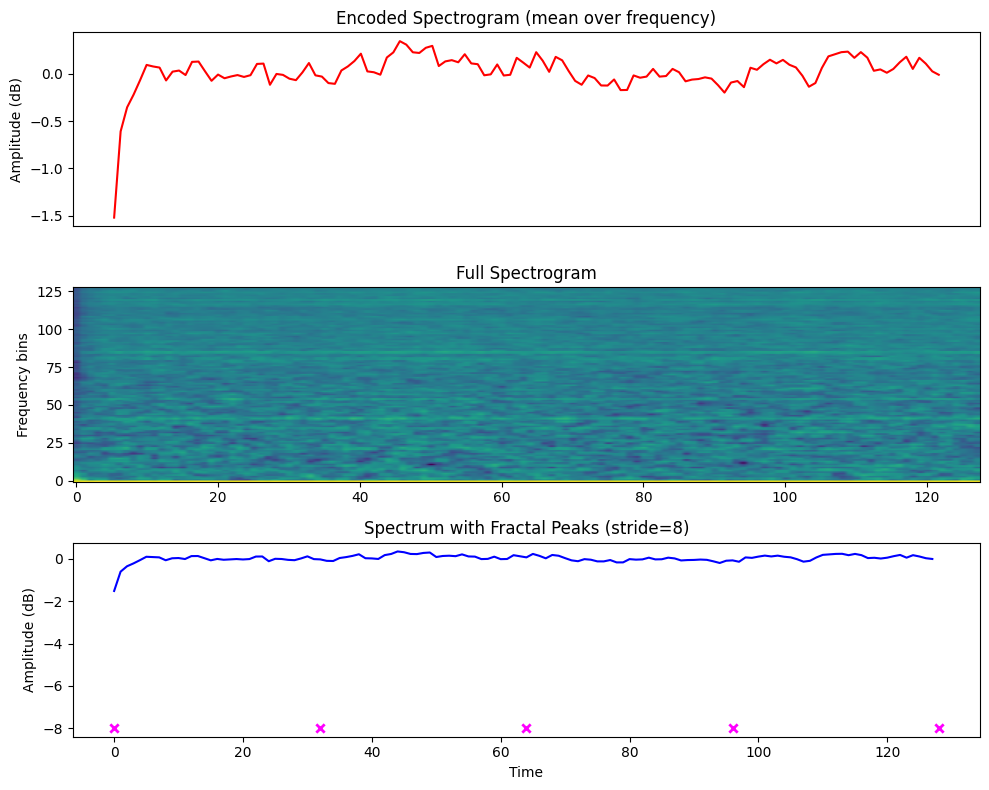

In [ ]:
# Compute STFT and fractal visualization through decoder layers
def compute_stft_fp(latent_tensor, n_fft=8192):
    """Compute STFT spectrogram from latent tensor."""
    stft = torch.stft(latent_tensor.squeeze(), n_fft=n_fft, return_complex=True)
    stft_mag = torch.abs(stft).numpy()
    stft_db = 10 * np.log10(np.clip(stft_mag, 1e-10, 1e6))
    return np.mean(stft_db, axis=0)  # Mean over frequency

def plot_fractal(k=8, N=4097, y_offset=0):
    x = [t * 2 * N / k for t in range(k // 2 + 1)]
    plt.scatter(x, [y_offset] * len(x), c="magenta", marker="x", linewidth=2, clip_on=False)

plt.figure(figsize=(10, 20))

# Input latent spectrum
input_fft = compute_stft_fp(audio_latent)
plt.subplot(7, 1, 1)
plt.plot(input_fft, color="red")
plt.title("Input Latent Spectrum")
plt.yticks([])

# Through decoder layers [4, 7, 10, 13]
ffts = []
for i, layer_idx in enumerate([4, 7, 10, 13], 1):
    with torch.no_grad():
        latent = model.decoder.model[2:layer_idx](audio_latent)
    fft = compute_stft_fp(latent)
    ffts.append(fft)
    
    plt.subplot(7, 1, i + 1)
    plt.plot(fft)
    plt.title(f"Layer {layer_idx}")
    plt.yticks([])
    plot_fractal(k=[8, 5, 4, 2][i-1], y_offset=np.mean(fft) - 8)

# Output
with torch.no_grad():
    output = model.decoder.model[2:](audio_latent)
output_fft = compute_stft_fp(output)
plt.subplot(7, 1, 7)
plt.plot(output_fft, color="red")
plt.title("Output Spectrum")
plt.yticks([])

plt.tight_layout()
plt.show()